## Customer Churn Prediction

### Problem Statement
#### Predicting customer churn using customer demographic, service usage, contract, payment, tenure, and billing information, so that businesses can identify customers who are at risk of leaving and support customer-retention activities.
¶

### Preprocessing

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings("ignore")

#### Data Loading and Understanding

In [3]:
# Load the csv data to a dataframe
df=pd.read_csv("Telco_customer_churn.csv")
df.tail(3)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN
7042,3186-AJIEK,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,...,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No,0,38,5097,NaN


In [4]:
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [6]:
df_columns=df.columns
df_columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [7]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [8]:
print(f'Number of Duplicates: {df.duplicated().sum()}')

Number of Duplicates: 0


In [9]:
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6531
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


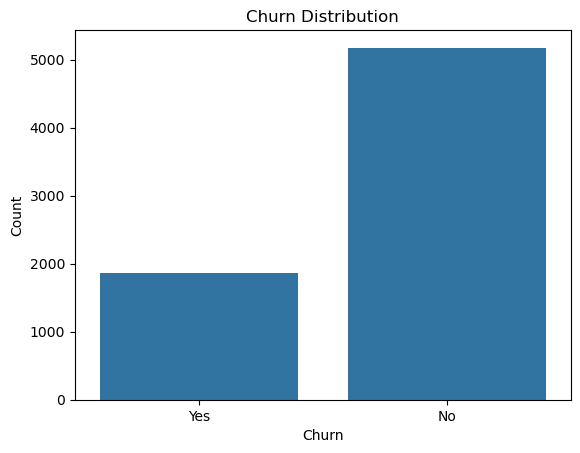

In [10]:
Target= df['Churn Label']
print(Target.value_counts())
print(df['Churn Label'].value_counts(normalize=True) * 100)

sns.countplot(x='Churn Label', data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [11]:
# Droping unwanted and leakage features
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

df = df.drop(columns=drop_columns)

In [12]:
print(df.shape)
print(df.columns)

(7043, 26)
Index(['City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'CLTV'],
      dtype='object')


In [13]:
df.dtypes

City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
CLTV                   int64
dtype: object

In [14]:
print("Numerical columns:")
print(df.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical columns:")
print(df.select_dtypes(include=["object"]).columns.tolist())

Numerical columns:
['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'CLTV']

Categorical columns:
['City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges', 'Churn Label']


#### Cleaning Numerical Features

In [15]:
num_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
Monthly Charges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
CLTV,7043.0,4400.295755,1183.057152,2003.00,3469.0,4527.00,5380.50,6500.00


In [16]:
print(df["Total Charges"].dtype)

object


In [17]:
print(df["Total Charges"].head(10))

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
5     528.35
6      39.65
7      20.15
8    4749.15
9       30.2
Name: Total Charges, dtype: object


In [18]:
print("Blank values:", (df["Total Charges"].astype(str).str.strip() == "").sum())

print("Non-numeric values:")
print(pd.to_numeric(df["Total Charges"], errors="coerce").isna().sum())

Blank values: 11
Non-numeric values:
11


In [19]:
# Converting Total charges from object to numeric value
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [20]:
print(df["Total Charges"].dtype)
print("Missing values:", df["Total Charges"].isna().sum())

float64
Missing values: 11


In [21]:
df[df["Total Charges"].isna()][
    ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Label"]
]

,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,0,52.55,NaN,No
2438,0,20.25,NaN,No
2568,0,80.85,NaN,No
2667,0,25.75,NaN,No
2856,0,56.05,NaN,No
4331,0,19.85,NaN,No
4687,0,25.35,NaN,No
5104,0,20.00,NaN,No
5719,0,19.70,NaN,No
6772,0,73.35,NaN,No


In [22]:
df.loc[df["Total Charges"].isna(), "Total Charges"] = 0
print("Missing Total Charges:", df["Total Charges"].isna().sum())

Missing Total Charges: 0


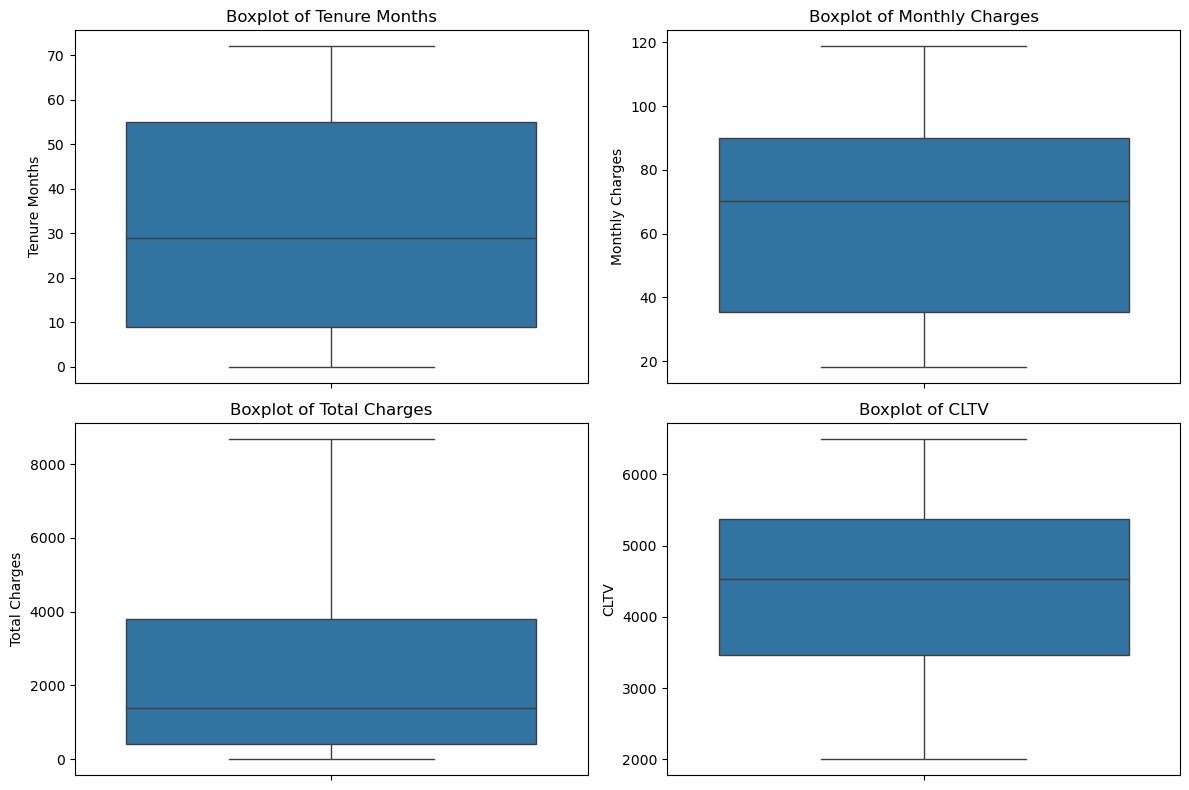

In [23]:
# Checking Outliers using Boxplot
num_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, ax in zip(num_cols, axes.flatten()):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

#### Cleaning Categorical features

In [24]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- City ---
City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Healdsburg          4
Jenner              4
Philo               4
Point Arena         4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64

--- Lat Long ---
Lat Long
33.964131, -118.272783    5
34.152875, -118.486056    5
32.912664, -116.635387    5
32.64164, -116.985026     5
32.607964, -117.059459    5
                         ..
37.4695, -120.672724      4
38.055562, -120.456298    4
38.244806, -120.417301    4
38.264262, -120.515133    4
39.191797, -120.212401    4
Name: count, Length: 1652, dtype: int64

--- Gender ---
Gender
Male      3555
Female    3488
Name: count, dtype: int64

--- Senior Citizen ---
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64

--- Dependents ---
Dependents
No     5416
Yes    1627
Name: count, dtype: int64


### 02. Exploratory Data Analysis (EDA)

Churn Label            No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


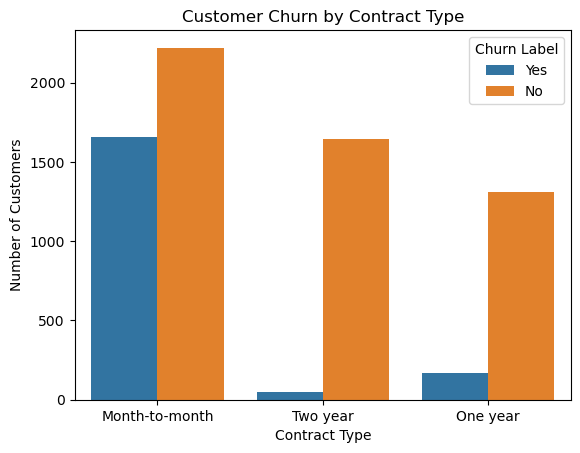

In [25]:
# Contract vs Churn
print(pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100)

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

             count       mean  median  min  max
Churn Label                                    
No            5174  37.569965    38.0    0   72
Yes           1869  17.979133    10.0    1   72


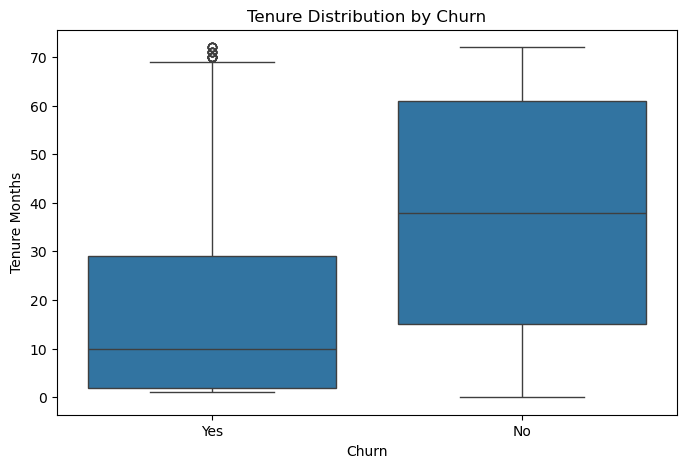

In [26]:
# Tenure vs Churn
print(df.groupby("Churn Label")["Tenure Months"].agg(
    ["count", "mean", "median", "min", "max"]
))

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure Months")
plt.show()

             count       mean  median    min     max
Churn Label                                         
No            5174  61.265124  64.425  18.25  118.75
Yes           1869  74.441332  79.650  18.85  118.35


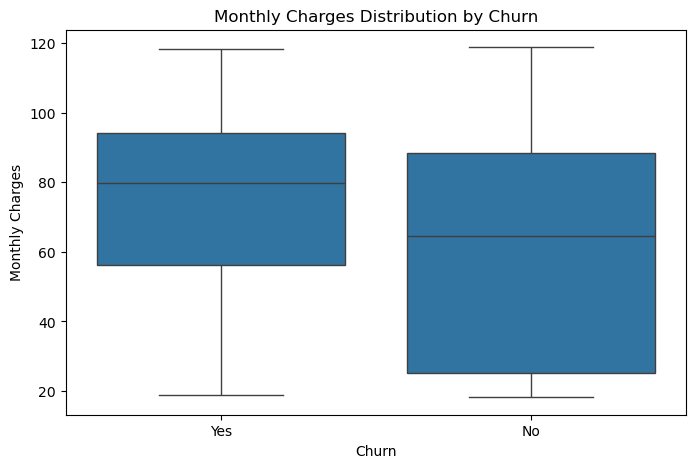

In [27]:
# Monthly Charges vs Churn
print(df.groupby("Churn Label")["Monthly Charges"].agg(
    ["count", "mean", "median", "min", "max"]
))

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

Churn Label              No        Yes
Internet Service                      
DSL               81.040892  18.959108
Fiber optic       58.107235  41.892765
No                92.595020   7.404980


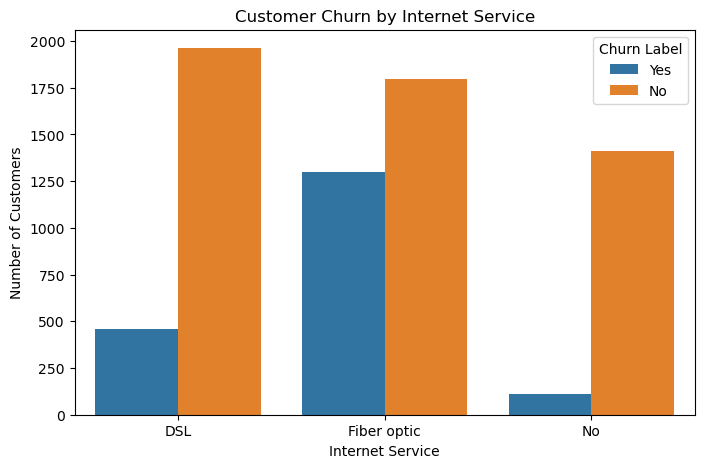

In [28]:
# Internet Service vs Churn
print(pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

Churn Label                       No        Yes
Payment Method                                 
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


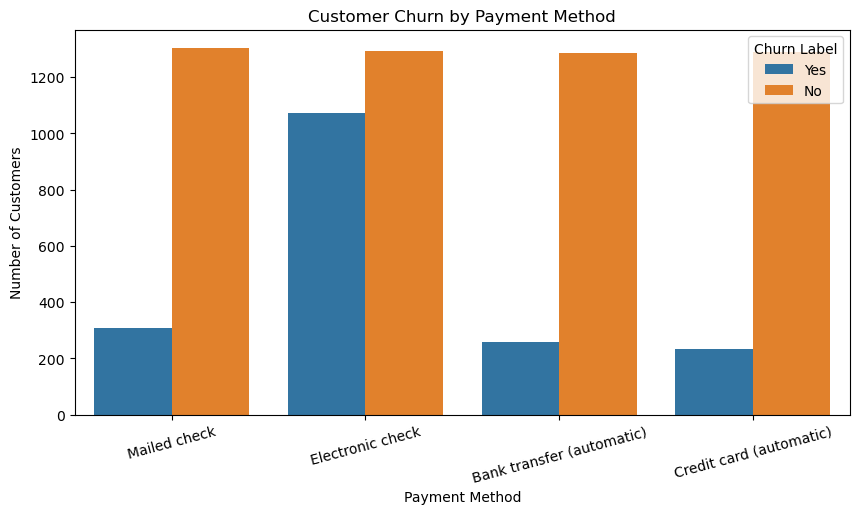

In [29]:
# Payment Method vs Churn
print(pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100)

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.show()

Churn Label            No        Yes
Senior Citizen                      
No              76.393832  23.606168
Yes             58.318739  41.681261


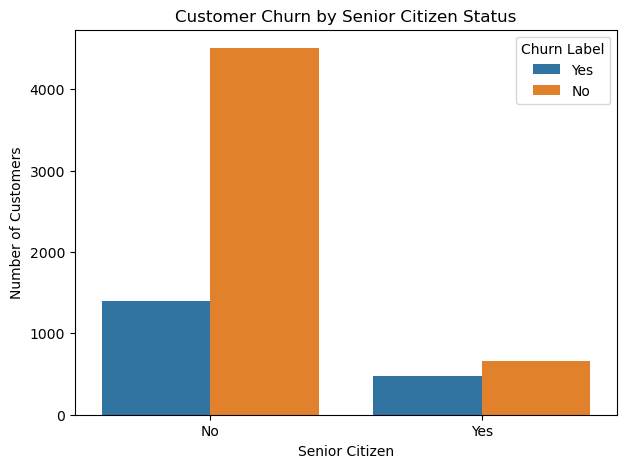

In [30]:
# Senior Citizen vs Churn.
print(pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
) * 100)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Senior Citizen",
    hue="Churn Label"
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

In [31]:
# Additional Services vs Churn
service_cols = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support"
]

for col in service_cols:
    print(f"\n--- {col} ---")
    print(
        pd.crosstab(
            df[col],
            df["Churn Label"],
            normalize="index"
        ) * 100
    )


--- Online Security ---
Churn Label                 No        Yes
Online Security                          
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

--- Online Backup ---
Churn Label                 No        Yes
Online Backup                            
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494

--- Device Protection ---
Churn Label                 No        Yes
Device Protection                        
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064

--- Tech Support ---
Churn Label                 No        Yes
Tech Support                             
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


             count         mean  median   min   max
Churn Label                                        
No            5174  4490.921337  4620.0  2003  6500
Yes           1869  4149.414660  4238.0  2003  6484


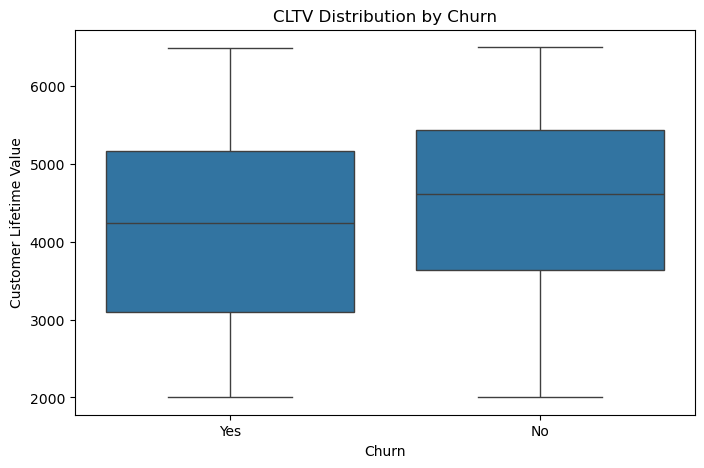

In [32]:
# CLTV vs Churn
print(df.groupby("Churn Label")["CLTV"].agg(
    ["count", "mean", "median", "min", "max"]
))

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="CLTV"
)

plt.title("CLTV Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Customer Lifetime Value")

plt.show()

             count         mean    median    min      max
Churn Label                                              
No            5174  2549.911442  1679.525   0.00  8672.45
Yes           1869  1531.796094   703.550  18.85  8684.80


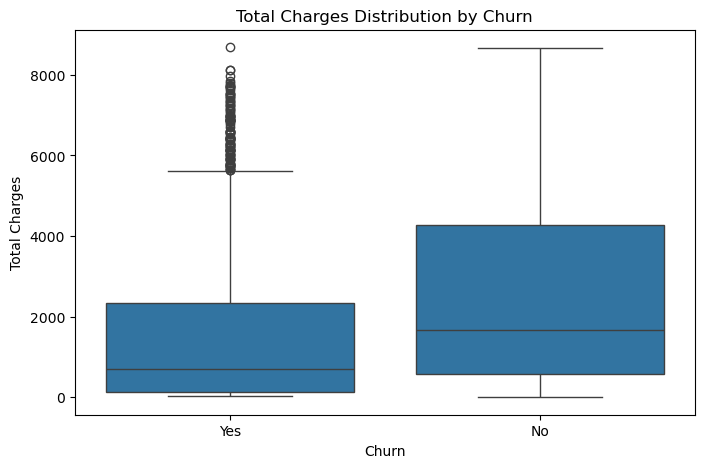

In [33]:
# Total Charges vs Churn
print(df.groupby("Churn Label")["Total Charges"].agg(
    ["count", "mean", "median", "min", "max"]
))

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Total Charges"
)

plt.title("Total Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

                 Tenure Months  Monthly Charges  Total Charges      CLTV
Tenure Months         1.000000         0.247900       0.826178  0.396406
Monthly Charges       0.247900         1.000000       0.651174  0.098693
Total Charges         0.826178         0.651174       1.000000  0.342091
CLTV                  0.396406         0.098693       0.342091  1.000000


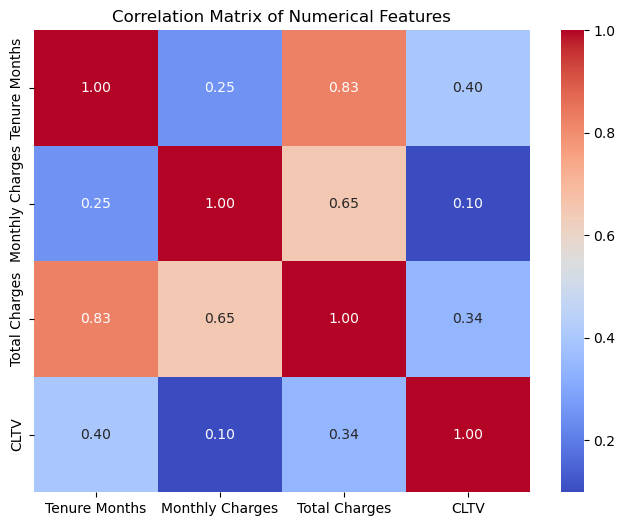

In [34]:
# Check correlation between numerical features
num_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

corr = df[num_cols].corr()

print(corr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [35]:
# Check whether location is useful for churn
location_cols = [
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

for col in location_cols:
    print("\n", col)
    print(pd.crosstab(
        df[col],
        df["Churn Label"],
        normalize="index"
    ).sort_values("Yes", ascending=False).head(10))
    


 City
Churn Label     No  Yes
City                   
Fort Jones     0.0  1.0
Eldridge       0.0  1.0
Maricopa       0.0  1.0
Boulder Creek  0.0  1.0
Riverbank      0.0  1.0
Twain          0.0  1.0
Johannesburg   0.0  1.0
Smith River    0.0  1.0
Tipton         0.0  1.0
Wrightwood     0.0  1.0

 Zip Code
Churn Label   No  Yes
Zip Code             
96161        0.0  1.0
95567        0.0  1.0
93528        0.0  1.0
93711        0.0  1.0
94014        0.0  1.0
95984        0.0  1.0
93272        0.0  1.0
93252        0.0  1.0
96032        0.0  1.0
93110        0.0  1.0

 Lat Long
Churn Label              No  Yes
Lat Long                        
37.171727, -122.142961  0.0  1.0
38.348884, -122.51699   0.0  1.0
34.066367, -118.309868  0.0  1.0
36.833002, -119.82947   0.0  1.0
34.358321, -117.618263  0.0  1.0
34.437945, -119.77191   0.0  1.0
34.737031, -119.460557  0.0  1.0
37.734971, -120.954271  0.0  1.0
41.5837, -122.935922    0.0  1.0
36.047414, -119.344304  0.0  1.0

 Latitude
Churn Label 

In [36]:
# Removing all 5 locations which is unnecesssary
location_cols = [
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

df = df.drop(columns=location_cols)

print(df.columns)
print(df.shape)

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'CLTV'],
      dtype='object')
(7043, 21)


In [37]:
# Separate target from features
X = df.drop(columns=["Churn Label"])
y = df["Churn Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (7043, 20)
y shape: (7043,)

Target distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [38]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']

Numerical columns:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']


In [54]:
df.to_csv("cleaned_Customer_Churn.csv", index=False)
df1 = pd.read_csv("cleaned_Customer_Churn.csv")
df1.head(3)

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,CLTV
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3239
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2701
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,5372


### Train-Test Split

In [39]:
# Splitting Data into train and test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 20)
X_test: (1409, 20)
y_train: (5634,)
y_test: (1409,)


#### Encode categorical + scale numerical features

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (5634, 47)
X_test_processed shape: (1409, 47)


In [41]:
print("Missing values in X_train:",
      np.isnan(X_train_processed).sum())

print("Missing values in X_test:",
      np.isnan(X_test_processed).sum())

Missing values in X_train: 0
Missing values in X_test: 0


### 03. Model Building

In [42]:
# Importing Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [43]:
# Convert target labels for XGBoost
y_train_xgb = y_train.map({"No": 0, "Yes": 1})
y_test_xgb = y_test.map({"No": 0, "Yes": 1})

In [44]:
# 1. Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

# 2. SVM
svm_model = LinearSVC()

# 3. Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 4. XGBoost
xgboost_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

In [45]:
# Train Logistic Regression
logistic_model.fit(X_train_processed, y_train)
y_pred_lr = logistic_model.predict(X_test_processed)

# Train SVM
svm_model.fit(X_train_processed, y_train)
y_pred_svm = svm_model.predict(X_test_processed)


# Train Random Forest
random_forest_model.fit(X_train_processed, y_train)
y_pred_rf = random_forest_model.predict(X_test_processed)


# Train XGBoost
xgboost_model.fit(X_train_processed, y_train_xgb)
# Predict
y_pred_xgb = xgboost_model.predict(X_test_processed)
# Convert predictions back to original labels
y_pred_xgb = pd.Series(y_pred_xgb).map({0: "No", 1: "Yes"}).values

print("All 5 models trained and predictions generated successfully.")

All 5 models trained and predictions generated successfully.


### 04. Evaluation

In [46]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns


def eval_clf(y, yhat):

    # Confusion Matrix
    cm = confusion_matrix(y, yhat, labels=["No", "Yes"])

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No", "Yes"],
        yticklabels=["No", "Yes"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")

    plt.show()


    # Classification Report
    print("Classification Report:")
    print(
        classification_report(
            y,
            yhat,
            labels=["No", "Yes"],
            target_names=["No Churn", "Churn"]
        )
    )


    # Evaluation Metrics
    precision = precision_score(y, yhat, pos_label="Yes")
    recall = recall_score(y, yhat, pos_label="Yes")
    accuracy = accuracy_score(y, yhat)
    f1 = f1_score(y, yhat, pos_label="Yes")


    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"F1-Score:  {f1:.4f}")

===== Logistic Regression =====


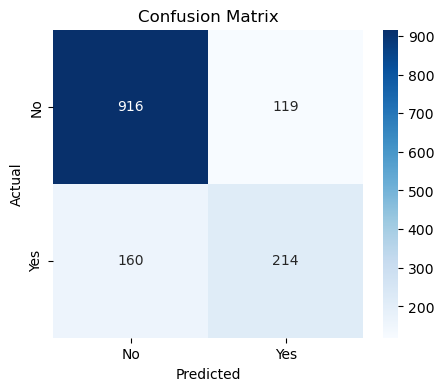

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.64      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409

Precision: 0.6426
Recall:    0.5722
Accuracy:  0.8020
F1-Score:  0.6054


In [47]:
print("===== Logistic Regression =====")
eval_clf(y_test, y_pred_lr)

===== SVM =====


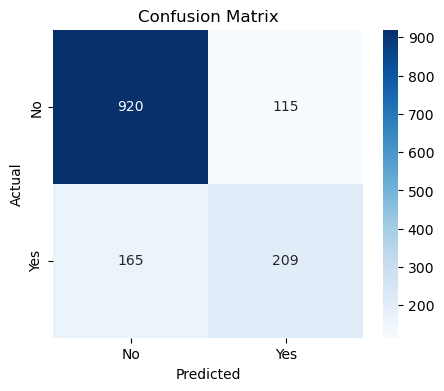

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

Precision: 0.6451
Recall:    0.5588
Accuracy:  0.8013
F1-Score:  0.5989


In [48]:
print("===== SVM =====")
eval_clf(y_test, y_pred_svm)

===== Random Forest =====


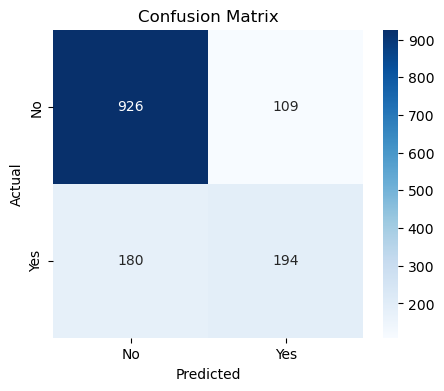

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409

Precision: 0.6403
Recall:    0.5187
Accuracy:  0.7949
F1-Score:  0.5731


In [49]:
print("===== Random Forest =====")
eval_clf(y_test, y_pred_rf)

===== XGBoost =====


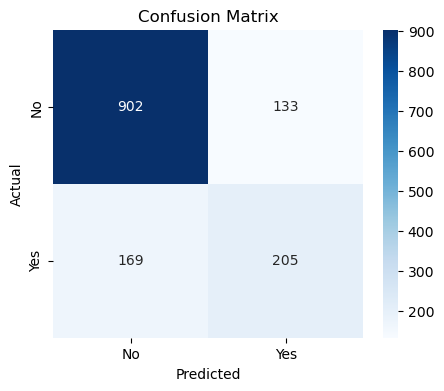

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.87      0.86      1035
       Churn       0.61      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409

Precision: 0.6065
Recall:    0.5481
Accuracy:  0.7857
F1-Score:  0.5758


In [50]:
print("===== XGBoost =====")
eval_clf(y_test, y_pred_xgb)

#### Compare Evaluation Table 

In [51]:
results = []

models_predictions = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for model_name, y_pred in models_predictions.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label="Yes"),
        "Recall": recall_score(y_test, y_pred, pos_label="Yes"),
        "F1": f1_score(y_test, y_pred, pos_label="Yes")
    })

comparison_df = pd.DataFrame(results)

print(comparison_df.round(4))

                 Model  Accuracy  Precision  Recall      F1
0  Logistic Regression    0.8020     0.6426  0.5722  0.6054
1                  SVM    0.8013     0.6451  0.5588  0.5989
2        Random Forest    0.7949     0.6403  0.5187  0.5731
3              XGBoost    0.7857     0.6065  0.5481  0.5758


#### ROC-AUC Score

In [52]:
from sklearn.metrics import roc_auc_score

# Convert target to 0/1
y_test_binary = y_test.map({"No": 0, "Yes": 1})

# Get scores/probabilities

# Logistic Regression
lr_score = logistic_model.predict_proba(X_test_processed)[:, 1]

# SVM
svm_score = svm_model.decision_function(X_test_processed)

# Random Forest
rf_score = random_forest_model.predict_proba(X_test_processed)[:, 1]

# XGBoost
xgb_score = xgboost_model.predict_proba(X_test_processed)[:, 1]


# Calculate ROC-AUC
roc_results = {
    "Logistic Regression": roc_auc_score(y_test_binary, lr_score),
    "Decision Tree": roc_auc_score(y_test_binary, dt_score),
    "SVM": roc_auc_score(y_test_binary, svm_score),
    "Random Forest": roc_auc_score(y_test_binary, rf_score),
    "XGBoost": roc_auc_score(y_test_binary, xgb_score)
}

print("ROC-AUC Scores:")
for model, score in roc_results.items():
    print(f"{model}: {score:.4f}")

NameError: name 'dt_score' is not defined

### 05. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# For Loggistic Regression
lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(X_train_processed, y_train)

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("Best CV F1 Score:")
print(lr_grid.best_score_)

In [ ]:
# For SVM
svm_params = {
    "C": [0.01, 0.1, 1, 10, 100]
}

svm_grid = GridSearchCV(
    LinearSVC(),
    svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train_processed, y_train)

print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("Best CV F1 Score:")
print(svm_grid.best_score_)

In [ ]:
# For Random Forest
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train_processed, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best CV F1 Score:")
print(rf_grid.best_score_)

In [ ]:
# For XG Boosing
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train_processed, y_train_xgb)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

print("Best CV F1 Score:")
print(xgb_grid.best_score_)

In [ ]:
y_train_num = y_train.map({"No": 0, "Yes": 1})
y_test_num = y_test.map({"No": 0, "Yes": 1})

In [ ]:
print(y_train_num.value_counts())

In [ ]:


lr_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    error_score="raise"
)

lr_grid.fit(X_train_processed, y_train_num)

print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("Best CV F1 Score:")
print(lr_grid.best_score_)

In [ ]:
best_lr = lr_grid.best_estimator_

y_pred_lr_tuned_num = best_lr.predict(X_test_processed)

# Convert predictions back to No/Yes
y_pred_lr_tuned = pd.Series(
    y_pred_lr_tuned_num
).map({0: "No", 1: "Yes"}).values

In [ ]:
eval_clf(y_test, y_pred_lr_tuned)

In [ ]:
svm_params = {
    "C": [0.01, 0.1, 1, 10, 100]
}

svm_grid = GridSearchCV(
    LinearSVC(),
    svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    error_score="raise"
)

svm_grid.fit(X_train_processed, y_train_num)

print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("Best CV F1 Score:")
print(svm_grid.best_score_)

In [ ]:
best_svm = svm_grid.best_estimator_

# Predict using tuned SVM
y_pred_svm_tuned_num = best_svm.predict(X_test_processed)

# Convert 0/1 predictions back to No/Yes
y_pred_svm_tuned = pd.Series(
    y_pred_svm_tuned_num
).map({
    0: "No",
    1: "Yes"
}).values

# Evaluate
eval_clf(y_test, y_pred_svm_tuned)

In [ ]:
y_pred_dt_tuned_num = best_dt.predict(X_test_processed)

y_pred_dt_tuned = pd.Series(
    y_pred_dt_tuned_num
).map({0: "No", 1: "Yes"}).values

eval_clf(y_test, y_pred_dt_tuned)

In [ ]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    error_score="raise"
)

rf_grid.fit(X_train_processed, y_train_num)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best CV F1 Score:")
print(rf_grid.best_score_)

In [ ]:
best_rf = rf_grid.best_estimator_

y_pred_rf_tuned_num = best_rf.predict(X_test_processed)

# Convert 0/1 back to No/Yes
y_pred_rf_tuned = pd.Series(
    y_pred_rf_tuned_num
).map({
    0: "No",
    1: "Yes"
}).values

# Evaluate
eval_clf(y_test, y_pred_rf_tuned)

In [ ]:
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    error_score="raise"
)

xgb_grid.fit(X_train_processed, y_train_num)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

print("Best CV F1 Score:")
print(xgb_grid.best_score_)

In [ ]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb_tuned_num = best_xgb.predict(X_test_processed)

# Convert 0/1 predictions back to No/Yes
y_pred_xgb_tuned = pd.Series(
    y_pred_xgb_tuned_num
).map({
    0: "No",
    1: "Yes"
}).values

# Evaluate
eval_clf(y_test, y_pred_xgb_tuned)

In [ ]:
from sklearn.metrics import roc_auc_score

# Logistic Regression
lr_prob_tuned = best_lr.predict_proba(X_test_processed)[:, 1]

# SVM
svm_score_tuned = best_svm.decision_function(X_test_processed)

# Random Forest
rf_prob_tuned = best_rf.predict_proba(X_test_processed)[:, 1]

# XGBoost
xgb_prob_tuned = best_xgb.predict_proba(X_test_processed)[:, 1]


# Tuned ROC-AUC
tuned_roc_results = {
    "Logistic Regression": roc_auc_score(y_test_num, lr_prob_tuned),
    "SVM": roc_auc_score(y_test_num, svm_score_tuned),
    "Random Forest": roc_auc_score(y_test_num, rf_prob_tuned),
    "XGBoost": roc_auc_score(y_test_num, xgb_prob_tuned)
}

print("Tuned ROC-AUC Scores:")

for model, score in tuned_roc_results.items():
    print(f"{model}: {score:.4f}")

In [ ]:


# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Create feature importance dataframe
xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_xgb.feature_importances_
}).sort_values("Importance", ascending=False)

# Display top 15 features
print(xgb_importance.head(15))

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Tuned XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.7984,
        0.8013,
        0.8020,
        0.8034
    ],
    "Precision": [
        0.6339,
        0.6451,
        0.6557,
        0.6570
    ],
    "Recall": [
        0.5695,
        0.5588,
        0.5348,
        0.5428
    ],
    "F1-Score": [
        0.6000,
        0.5989,
        0.5800,
        0.5944
    ],
    "ROC-AUC": [
        0.8481,
        0.8444,
        0.8511,
        0.8543
    ]
})

print(final_results)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Get churn probabilities
y_prob_xgb = best_xgb.predict_proba(X_test_processed)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy : {accuracy_score(y_test_num, y_pred_threshold):.4f}")
    print(f"Precision: {precision_score(y_test_num, y_pred_threshold):.4f}")
    print(f"Recall   : {recall_score(y_test_num, y_pred_threshold):.4f}")
    print(f"F1-Score : {f1_score(y_test_num, y_pred_threshold):.4f}")

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
# Final predictions using threshold 0.3
y_pred_final = (y_prob_xgb >= 0.3).astype(int)

# Convert to labels
y_pred_final_labels = pd.Series(y_pred_final).map({
    0: "No",
    1: "Yes"
}).values

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_final_labels,
    labels=["No", "Yes"]
)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final XGBoost Confusion Matrix")
plt.show()

# Classification Report
print("Final XGBoost Classification Report")
print(
    classification_report(
        y_test,
        y_pred_final_labels,
        labels=["No", "Yes"],
        target_names=["No Churn", "Churn"]
    )
)

In [ ]:
import joblib

# Save all 5 tuned models
joblib.dump(best_lr, "logistic_model.pkl")
joblib.dump(best_dt, "decision_tree_model.pkl")
joblib.dump(best_svm, "svm_model.pkl")
joblib.dump(best_rf, "random_forest_model.pkl")
joblib.dump(best_xgb, "xgboost_model.pkl")

# Save preprocessing pipeline
joblib.dump(preprocessor, "churn_preprocessor.pkl")

# Save XGBoost threshold
joblib.dump(0.3, "xgboost_threshold.pkl")

print("All model files saved successfully!")

### 06. Deployment

In [53]:
import os

files = [
    "logistic_model.pkl",
    "svm_model.pkl",
    "random_forest_model.pkl",
    "xgboost_model.pkl",
    "churn_preprocessor.pkl",
    "xgboost_threshold.pkl"
]

for file in files:
    print(file, "->", "Exists" if os.path.exists(file) else "Missing")

logistic_model.pkl -> Exists
svm_model.pkl -> Exists
random_forest_model.pkl -> Exists
xgboost_model.pkl -> Exists
churn_preprocessor.pkl -> Exists
xgboost_threshold.pkl -> Exists
